#### Teoría de los Circuitos 2
# Trabajo de Laboratorio #2
#### Leandro Robledo

### [Introduccion](#intro)

### Análisis y Simulación [( Pre-Lab )](#prelab)

### Medición [( In-Lab )](#medicion)

### [Conclusion](#conclusion) 

Las conexiones con el kit de desarrollo se detallan a continuación:

PIN / DESCRIPCIÓN

CN6 - PIN 6 / GND

CN6 - PIN 4 / +5 VDC

CN8 - PIN 1 / ADC_IN

CN8 - PIN 3 / DAC_OUT


## Introduccion <a id="intro"></a>
En el presente trabajo de laboratorio se realizaron un filtro pasabsajos $  Chebyshev, $ con las siguientes caracteristitcas: Frecuecnia de paso de $100 Hz$, frecuencia de stop de $300 Hz$, $\alpha_{min}= 1 dB$ y un $\alpha_{max}= 60 dB$. Tambien se diseño un filtro pasabanda de tipo $\textbf{Notch}$, de una frecuencia de stop de $50Hz$ con $3db$ de ripple en un ancho de banda maximo de $1 db$. El primero de estos fue diseñado de tipo FIR (Finite Impulse Response), mientras que el segundo fue con un diesño IIR (Infinite Impulse Response).

El motivo de este trabajo de laboratorio es el de demostrar y comparar las ventajas y desventajas del filtrado digital frente del analogico, analizando aspectos como la exactitud, velocidad de respuesta y capacidad de diseño de estos filtros asi como su tiempo de desarrollo y complejidad empleada. 

El desarrollo del trabajo se estructuró en distintas etapas, correspondientes a las fases de diseño, simulación y validación experimental. En primer lugar se realizo el diseño digital con las funciones de Python arm_fir_f32 e iirdesign para cada uno respectivamente, verificando que cumplan las plantillas correspondientes solicitadas. Una vez obtenidos sus coeficientes se pasaron al STM32CubeIDE para trasnferirlos al microprocesador empleado en el trabajo. Para su uso se tuvieron que acoplar dos filtros pasabajos, en la entrada y salida respectivamente del ADC y del DAC de la plaqueta. 

Finalmente en la etapa de laboratorio se tomaron las mediciones respectivas para la realizacion de este informe, lo que incluyo un barrido en frecuencia utilizando un osciloscopio digital y otro con un alaizador de espectros de forma de poder contrastar estos resultados con los ideales.   


## Análisis y Simulacion ( Pre-Lab )<a id="prelab"></a>
Como fue mencionado se utilizaron codigos en Python para la obtencion de los respectivos coeficientes de los filtros para posteriormente ser empleados en el codigo facilitado por el profesor de manera de simplificar el trabajo sobre el microprocesador y enfocar los esfuerzos en el cumplimiento de los requerimientos de las respectivas plantillas. 

Para el diseño del filtro Pasabajos Chebyshev se utilizo el siguiente codigo:


[-2.47757708e-04 -2.52169478e-04 -2.58154179e-04 -2.65691169e-04
 -2.74663821e-04 -2.84912229e-04 -2.96171132e-04 -3.08131147e-04
 -3.20369711e-04 -3.32424127e-04 -3.43712353e-04 -3.53621544e-04
 -3.61414966e-04 -3.66340164e-04 -3.67517656e-04 -3.64073380e-04
 -3.55004101e-04 -3.39339403e-04 -3.15977934e-04 -2.83884918e-04
 -2.41892432e-04 -1.88939280e-04 -1.23827420e-04 -4.55120547e-05
  4.71949110e-05  1.55275463e-04  2.79865567e-04  4.21835863e-04
  5.82227590e-04  7.61750966e-04  9.61311298e-04  1.18141042e-03
  1.42277978e-03  1.68566757e-03  1.97059865e-03  2.27752656e-03
  2.60674383e-03  2.95787388e-03  3.33096001e-03  3.72526663e-03
  4.14058127e-03  4.57578777e-03  5.03042322e-03  5.50297680e-03
  5.99275368e-03  6.49784148e-03  7.01734646e-03  7.54895375e-03
  8.09161947e-03  8.64262946e-03  9.20085582e-03  9.76318910e-03
  1.03285031e-02  1.08932931e-02  1.14565436e-02  1.20143426e-02
  1.25659246e-02  1.31069347e-02  1.36370374e-02  1.41513568e-02
  1.46502311e-02  1.51281

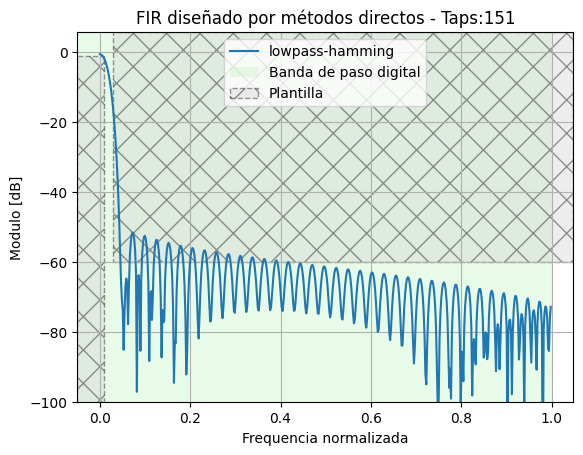

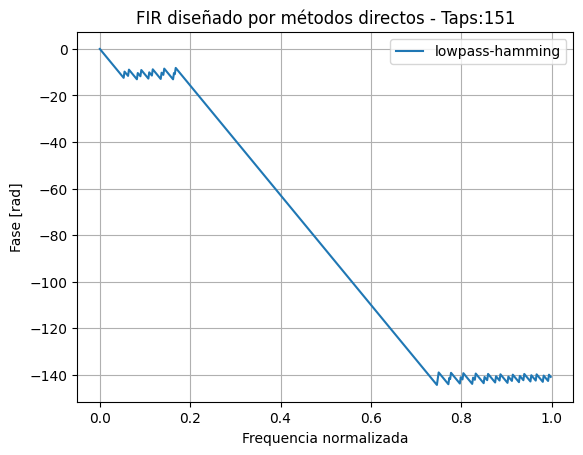

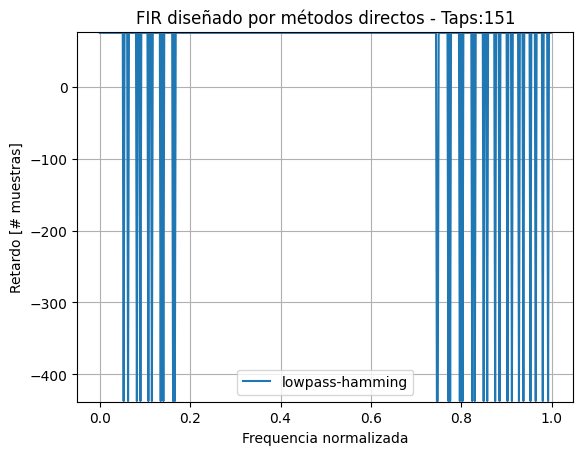

In [13]:
import sympy as sp
import numpy as np
import scipy.signal as sig
from scipy.signal.windows import hamming, kaiser, blackmanharris
import matplotlib.pyplot as plt

from pytc2.sistemas_lineales import plot_plantilla, group_delay

# frecuencia de muestreo normalizada
fs = 20*10**3
# tamaño de la respuesta al impulso
cant_coef = 151

filter_type = 'lowpass'

fpass = 100 # 
ripple = 1 # dB
fstop = 300 # Hz
attenuation = 60 # dB

f_predist = 60  #Hz

# construyo la plantilla de requerimientos
frecs = [0.0,  fpass + f_predist,   fstop - f_predist ,   fs/2]
gains = [0,   -ripple, -attenuation,   -np.inf] # dB

gains = 10**(np.array(gains)/20)


# FIR design
#num_bh = sig.firwin2(cant_coef, frecs, gains , window='blackmanharris' , 1000)
num_hm = sig.firwin2(cant_coef, frecs, gains , window='hamming', fs=fs)
#num_ka = sig.firwin2(cant_coef, frecs, gains , window=('kaiser',14) , fs=f1/2
                     
den = 1.0



def plot_freq_resp_fir(this_num, this_desc):

    wrad, hh = sig.freqz(this_num, 1.0)
    ww = wrad / np.pi
    
    plt.figure(1)

    plt.plot(ww, 20 * np.log10(abs(hh)), label=this_desc)

    plt.title('FIR diseñado por métodos directos - Taps:' + str(cant_coef) )
    plt.xlabel('Frequencia normalizada')
    plt.ylabel('Modulo [dB]')
    plt.grid(which='both', axis='both')

    axes_hdl = plt.gca()
    axes_hdl.legend()
    
    plt.figure(2)

    phase = np.unwrap(np.angle(hh))

    plt.plot(ww, phase, label=this_desc)

    plt.title('FIR diseñado por métodos directos - Taps:' + str(cant_coef))
    plt.xlabel('Frequencia normalizada')
    plt.ylabel('Fase [rad]')
    plt.grid(which='both', axis='both')

    axes_hdl = plt.gca()
    axes_hdl.legend()

    plt.figure(3)

    gd_win = group_delay(wrad, phase)

    plt.plot(ww, gd_win, label=this_desc)

    plt.ylim((np.min(gd_win[2:-2])-1, np.max(gd_win[2:-2])+1))
    plt.title('FIR diseñado por métodos directos - Taps:' + str(cant_coef))
    plt.xlabel('Frequencia normalizada')
    plt.ylabel('Retardo [# muestras]')
    plt.grid(which='both', axis='both')

    axes_hdl = plt.gca()
    axes_hdl.legend()    

plt.close('all')

#plot_freq_resp_fir(num_bh, filter_type+ '-blackmanharris')    
plot_freq_resp_fir(num_hm, filter_type+ '-hamming')    
#plot_freq_resp_fir(num_ka, filter_type+ '-kaiser-b14')    
    
    
# sobreimprimimos la plantilla del filtro requerido para mejorar la visualización    
fig = plt.figure(1)    
plot_plantilla(filter_type = filter_type,
                fpass = fpass/(fs/2),
                ripple = ripple,
                fstop = fstop/(fs/2),
                attenuation = attenuation,
                fs = 2)
ax = plt.gca()
ax.legend()

# reordenamos las figuras en el orden habitual: módulo-fase-retardo
plt.figure(2)    
axes_hdl = plt.gca()
axes_hdl.legend()

plt.figure(3)    
axes_hdl = plt.gca()
axes_hdl.legend()

print(num_hm)

plt.show()

### Diesño de filtro Notch IIR
El filtro Notch IIr fue realizado con el siguiente codigo:

SOS:
[[ 0.99984295 -1.99943919  0.99984295  1.         -1.99943919  0.99968589]]


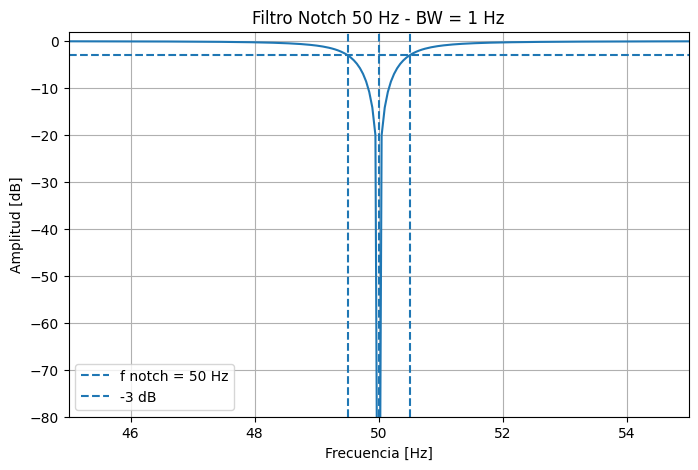

In [2]:
import numpy as np
from scipy import signal as sig
import sympy as sp
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
from pytc2.sistemas_lineales import pretty_print_lti
from pytc2.general import print_latex, a_equal_b_latex_s
from pytc2.cuadripolos import calc_MAI_ztransf_ij_mn
from pytc2.cuadripolos import calc_MAI_vtransf_ij_mn
import sympy as sp


# Especificaciones
f0 = 50.0
BW = 1.0
fs_muestreo = 20000.0

# Factor de calidad
Q = f0 / BW

# Filtro notch
b, a = sig.iirnotch(f0, Q, fs=fs_muestreo)

# Lo paso a SOS para trabajar igual que antes
sos = sig.tf2sos(b, a)

print("SOS:")
print(sos)

# Respuesta en frecuencia
w, h = sig.sosfreqz(
    sos,
    worN=200000,
    fs=fs_muestreo
)

plt.figure(figsize=(8,5))

plt.plot(
    w,
    20*np.log10(np.maximum(np.abs(h), 1e-8))
)

plt.axvline(f0, linestyle='--', label='f notch = 50 Hz')

# Bordes de BW de 1 Hz
plt.axvline(49.5, linestyle='--')
plt.axvline(50.5, linestyle='--')

plt.axhline(-3, linestyle='--', label='-3 dB')

plt.xlim(45, 55)
plt.ylim(-80, 2)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.title('Filtro Notch 50 Hz - BW = 1 Hz')

plt.grid(True)
plt.legend()
plt.show()

## Mediciones, Analizador de espectros <a id="medicion"></a>
Se uso un analizador de espectros para tomar 3 muestras de diferentes filtros
El primero se planteo un filtro pasatodo en el microporcesador ya que se buscaba ver la atenuacion que proponian los filtros analogicos colocados en la entrada y salida para atenuar el efecto de alias. Se obtuvo la siguiente respuesta donde se ve una atenuacion de apenas unos 4 db pasando los 4 KHz, esto es algo esperable debido a la simpleza de los filtros al componerse simplemente de un un circuito RC de una sola etapa.

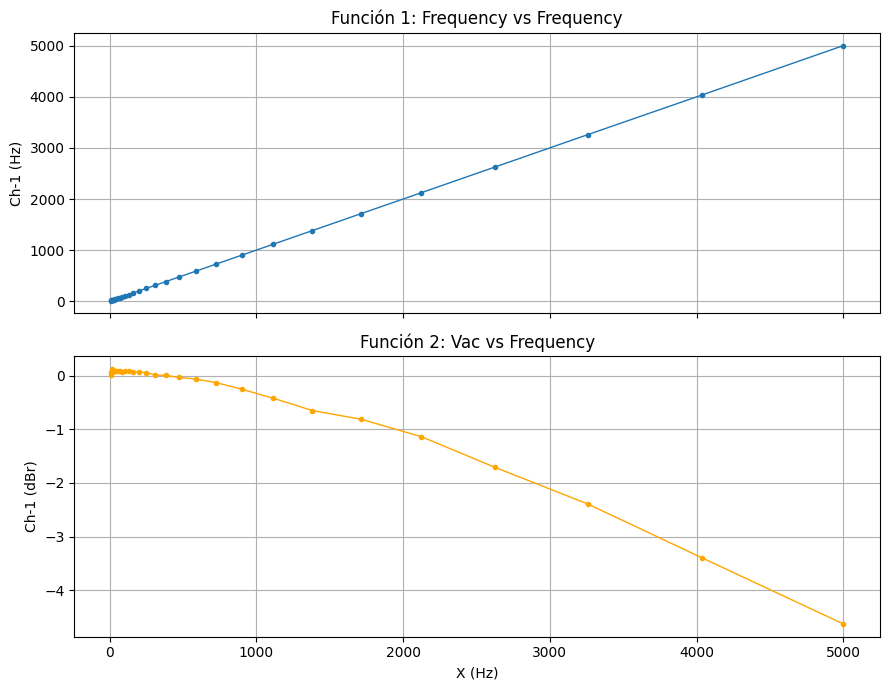

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import re

path = "LAB2/Sweep Data_2.csv"  # cambiá por la ruta real de tu archivo

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

def parse_block(lines_block):
    rows = []
    for line in lines_block:
        line = line.strip()
        if not line or "Sweep" in line or "vs Frequency" in line or "Ch-1" in line:
            continue
        parts = line.split(",")
        # nos quedamos solo con filas bien formadas: "numero,numero"
        if len(parts) == 2:
            try:
                x = float(parts[0])
                y = float(parts[1])
                rows.append((x, y))
            except ValueError:
                continue  # descarta filas corruptas tipo "480.961.843..."
    return pd.DataFrame(rows, columns=["Frequency_Hz", "Value"])

# separamos el archivo en los dos bloques (Function 1 y Function 2)
split_idx = next(i for i, l in enumerate(lines) if "Function 2" in l)

df1 = parse_block(lines[:split_idx])
df2 = parse_block(lines[split_idx:])

fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axs[0].plot(df1["Frequency_Hz"], df1["Value"], marker=".", lw=1)
axs[0].set_ylabel("Ch-1 (Hz)")
axs[0].set_title("Función 1: Frequency vs Frequency")
axs[0].grid(True)

axs[1].plot(df2["Frequency_Hz"], df2["Value"], marker=".", lw=1, color="orange")
axs[1].set_ylabel("Ch-1 (dBr)")
axs[1].set_xlabel("X (Hz)")
axs[1].set_title("Función 2: Vac vs Frequency")
axs[1].grid(True)

plt.tight_layout()
plt.show()

2. Como segunda muestra se realiza la prueba sobre el filtro Pasabajos Chebyshev, donde se puede apreciar una respuesta bastante similar a la esperada en el ideal. De este grafico podemos distinguir dos cosas fundamentales de la naturaleza de estos filtros, la primera la calidad de este que si bien se emplearon 151 taps, esto representa un numero considerablemetne bajo permitiendo una gran resolucion, a su vez es de destacar la fase perfectamente lineal que se aprecia que posee este tipo de filtro, una gran caracteristica de estos mismos que permite preservar la forma de la señal lo que hace que estos tipos de filtros sean muy usados en audio o señales biomedicas.

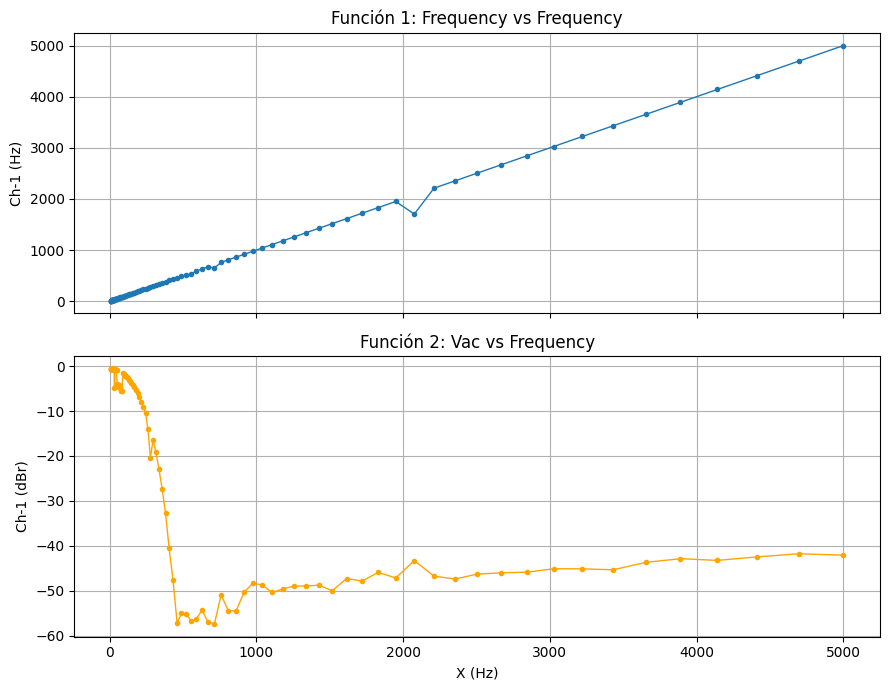

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import re

path = "LAB2/Sweep Data_1.csv"  # cambiá por la ruta real de tu archivo

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

def parse_block(lines_block):
    rows = []
    for line in lines_block:
        line = line.strip()
        if not line or "Sweep" in line or "vs Frequency" in line or "Ch-1" in line:
            continue
        parts = line.split(",")
        # nos quedamos solo con filas bien formadas: "numero,numero"
        if len(parts) == 2:
            try:
                x = float(parts[0])
                y = float(parts[1])
                rows.append((x, y))
            except ValueError:
                continue  # descarta filas corruptas tipo "480.961.843..."
    return pd.DataFrame(rows, columns=["Frequency_Hz", "Value"])

# separamos el archivo en los dos bloques (Function 1 y Function 2)
split_idx = next(i for i, l in enumerate(lines) if "Function 2" in l)

df1 = parse_block(lines[:split_idx])
df2 = parse_block(lines[split_idx:])

fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axs[0].plot(df1["Frequency_Hz"], df1["Value"], marker=".", lw=1)
axs[0].set_ylabel("Ch-1 (Hz)")
axs[0].set_title("Función 1: Frequency vs Frequency")
axs[0].grid(True)

axs[1].plot(df2["Frequency_Hz"], df2["Value"], marker=".", lw=1, color="orange")
axs[1].set_ylabel("Ch-1 (dBr)")
axs[1].set_xlabel("X (Hz)")
axs[1].set_title("Función 2: Vac vs Frequency")
axs[1].grid(True)

plt.tight_layout()
plt.show()

3. Por ultimo se realizo el barrido en frecuencia del filtro IIR Notch, el cual si bien no se aprecia la mejor caracteristica esperada, esta no deja de ser una muy buena considerando la poca cantidad de recursos que utilza, llegando a tener una selectividad considerable teniendo en cuenta que ronda su ancho de banda al rededor de 1 Hz, acorde a lo solicitado. A su vez, cabe mencionar que el barrido en frecuencia podria haber sido posiblemente de mejor resolucion si se contara con mas tiempo de y frecuencia de medicion en la prueba, estos aspectos fueron acortados debido al tiempo que el analizador de espectro tarda en tomar las muestras en el dia de la practica.   

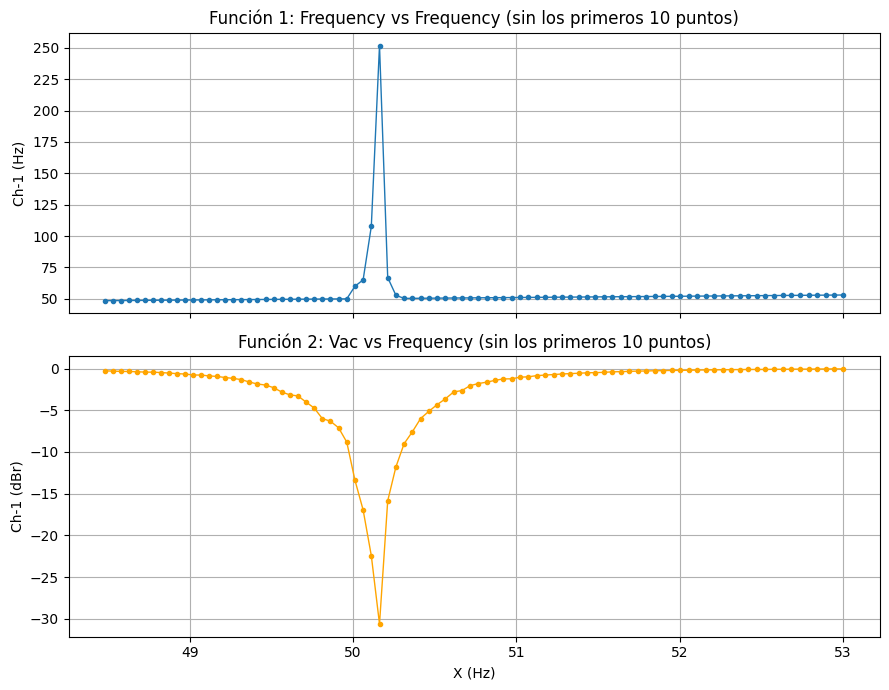

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

path = "LAB2/Sweep Data_0.csv"  # cambiá por la ruta real de tu archivo

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

def parse_block(lines_block, skip_first=0):
    rows = []
    for line in lines_block:
        line = line.strip()
        if not line or "Sweep" in line or "vs Frequency" in line or "Ch-1" in line:
            continue
        parts = line.split(",")
        if len(parts) == 2:
            try:
                x = float(parts[0])
                y = float(parts[1])
                rows.append((x, y))
            except ValueError:
                continue  # descarta filas corruptas tipo "480.961.843..."
    df = pd.DataFrame(rows, columns=["Frequency_Hz", "Value"])
    if skip_first > 0:
        df = df.iloc[skip_first:].reset_index(drop=True)
    return df

# separamos el archivo en los dos bloques (Function 1 y Function 2)
split_idx = next(i for i, l in enumerate(lines) if "Function 2" in l)

df1 = parse_block(lines[:split_idx], skip_first=10)
df2 = parse_block(lines[split_idx:], skip_first=10)

fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axs[0].plot(df1["Frequency_Hz"], df1["Value"], marker=".", lw=1)
axs[0].set_ylabel("Ch-1 (Hz)")
axs[0].set_title("Función 1: Frequency vs Frequency (sin los primeros 10 puntos)")
axs[0].grid(True)

axs[1].plot(df2["Frequency_Hz"], df2["Value"], marker=".", lw=1, color="orange")
axs[1].set_ylabel("Ch-1 (dBr)")
axs[1].set_xlabel("X (Hz)")
axs[1].set_title("Función 2: Vac vs Frequency (sin los primeros 10 puntos)")
axs[1].grid(True)

plt.tight_layout()
plt.show()

## Estudio de Comparacion

A contincuacion se mostraran los filtros obtenidos en comparacion con los esperados

1. Como se puede ver en este caso, la superposicon de las señales con el efecto alisasing podria estar generando esta distorcion que se aprecia en la señal una vez que aumenta la frecuencia, esto podria corregirse tal vez con el uso de otro tipo de ventana ya que la utilizada pareciera acompañar este fenomeno al aumentar tambien en altas frecuencias, o por le contrario y lo que deberia de tener mas efecto a la vez de no modificar la respuesta esperada seria mejorando los filtros analogicos colcoados en la entrada y salida del conversor analogico-digital respectivamente. 

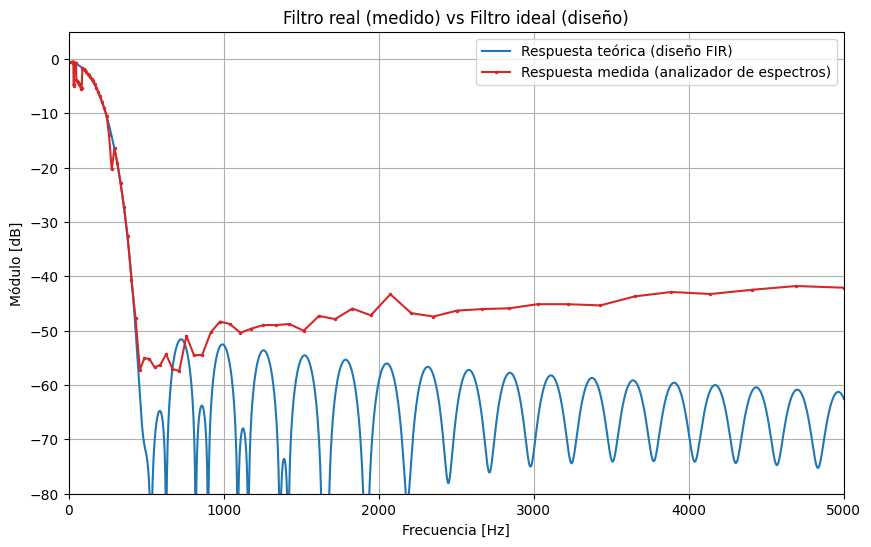

In [17]:
import pandas as pd
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

# ---------- 1) Cargar y parsear el CSV medido ----------

path = "LAB2/Sweep Data_1.csv"  # ajustá la ruta

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

def parse_block(lines_block, skip_first=0):
    rows = []
    for line in lines_block:
        line = line.strip()
        if not line or "Sweep" in line or "vs Frequency" in line or "Ch-1" in line:
            continue
        parts = line.split(",")
        if len(parts) == 2:
            try:
                x = float(parts[0])
                y = float(parts[1])
                rows.append((x, y))
            except ValueError:
                continue
    df = pd.DataFrame(rows, columns=["Frequency_Hz", "Value"])
    if skip_first > 0:
        df = df.iloc[skip_first:].reset_index(drop=True)
    return df

split_idx = next(i for i, l in enumerate(lines) if "Function 2" in l)
df_medido = parse_block(lines[split_idx:], skip_first=10)  # dBr vs Hz medidos

# ---------- 2) Respuesta teórica del filtro diseñado, en Hz ----------

n_puntos = 4096
wrad, hh = sig.freqz(num_hm, 1.0, worN=n_puntos, fs=fs)  # fs en Hz -> wrad sale en Hz
h_db_teorico = 20 * np.log10(np.abs(hh))

# ---------- 3) Gráfico comparativo ----------

plt.figure(figsize=(10, 6))
plt.plot(wrad, h_db_teorico, label='Respuesta teórica (diseño FIR)', color='tab:blue')
plt.plot(df_medido["Frequency_Hz"], df_medido["Value"], 
         label='Respuesta medida (analizador de espectros)', 
         color='tab:red', marker='.', linestyle='-', markersize=3)

plt.title('Filtro real (medido) vs Filtro ideal (diseño)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.xlim(0, max(df_medido["Frequency_Hz"].max(), fpass*3))  # ajustá el rango si querés ver más/menos
plt.ylim(-80, 5)
plt.grid(which='both', axis='both')
plt.legend()
plt.show()

2. Continuando con el analisis del Notch, se puede apreciar que si bien este no tiene una respuesta tan cercana a la ideal, ya que su maxima atenuacion esta rondando los -30 dB, esta es considerablemente buena teniendo en cuenta la simpleza del diseño y de los filtros analogicos empleados. esto demuestra que el uso de fultros digitales permite una buena calidad de filtrado con mucha facilidad. Cabe aclarar el posible ajuste fino sobre la frecuencia que se desea eliminar, ya que se observa un pequeño desvio de algunos mili Hertz. 

SOS:
[[ 0.99984295 -1.99943919  0.99984295  1.         -1.99943919  0.99968589]]


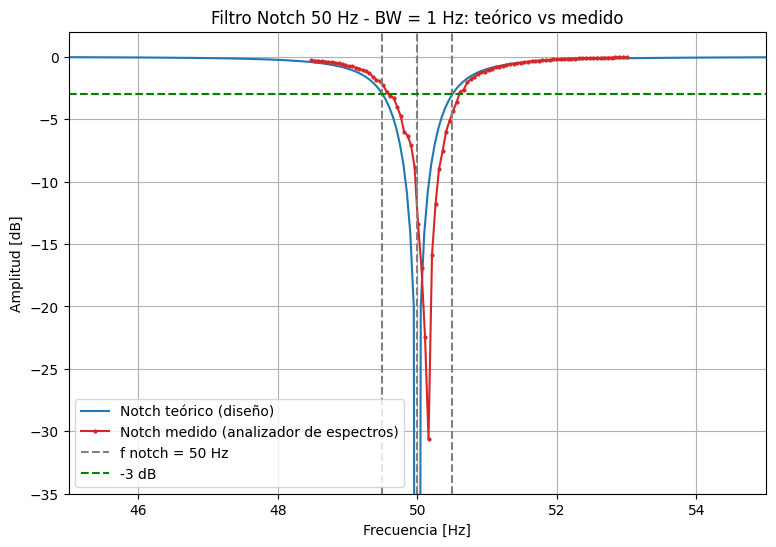

In [23]:
import numpy as np
import pandas as pd
from scipy import signal as sig
from matplotlib import pyplot as plt

# ---------- 1) Cargar y parsear el CSV medido ----------

path = "LAB2/Sweep Data_0.csv"  # ajustá la ruta

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

def parse_block(lines_block, skip_first=0):
    rows = []
    for line in lines_block:
        line = line.strip()
        if not line or "Sweep" in line or "vs Frequency" in line or "Ch-1" in line:
            continue
        parts = line.split(",")
        if len(parts) == 2:
            try:
                x = float(parts[0])
                y = float(parts[1])
                rows.append((x, y))
            except ValueError:
                continue
    df = pd.DataFrame(rows, columns=["Frequency_Hz", "Value"])
    if skip_first > 0:
        df = df.iloc[skip_first:].reset_index(drop=True)
    return df

split_idx = next(i for i, l in enumerate(lines) if "Function 2" in l)
df_medido = parse_block(lines[split_idx:], skip_first=10)  # dBr vs Hz medidos

# ---------- 2) Diseño teórico del notch (tu código original) ----------

f0 = 50.0
BW = 1.0
fs_muestreo = 20000.0

Q = f0 / BW

b, a = sig.iirnotch(f0, Q, fs=fs_muestreo)
sos = sig.tf2sos(b, a)

print("SOS:")
print(sos)

w, h = sig.sosfreqz(sos, worN=200000, fs=fs_muestreo)
h_db_teorico = 20*np.log10(np.maximum(np.abs(h), 1e-8))

# ---------- 3) Gráfico comparativo: medido vs teórico ----------

plt.figure(figsize=(9,6))

plt.plot(w, h_db_teorico, label='Notch teórico (diseño)', color='tab:blue')
plt.plot(df_medido["Frequency_Hz"], df_medido["Value"],
         label='Notch medido (analizador de espectros)',
         color='tab:red', marker='.', linestyle='-', markersize=4)

plt.axvline(f0, linestyle='--', color='gray', label='f notch = 50 Hz')
plt.axvline(49.5, linestyle='--', color='gray')
plt.axvline(50.5, linestyle='--', color='gray')

plt.axhline(-3, linestyle='--', color='green', label='-3 dB')

plt.xlim(45, 55)
plt.ylim(-35, 2)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.title('Filtro Notch 50 Hz - BW = 1 Hz: teórico vs medido')

plt.grid(True)
plt.legend()
plt.show()

### Conclusiones <a id="conclusiones"></a>
##### En este trabajo hemos logrado con creses el objetivo propueso de desarrollar los diferentes filtros digitales contra los analogicos realizados en el anterior trabajo de laboratorio. Se ha demostrasdo poder obtener resultados muy favorables y de una respuesta muy similar a la ideal esperada. Esto demuestra el poder de los microcontroladores y la facilidad que permite el uso del mismo dispositivo para diferentes filtros, algo que con un diseño analogico seria imposible. Sin embargo no todo es perfecto ya que, si bien la dispersion de los componentes asi como la complejidad del desarrollo en el diseño y montado de la plaqueta se ven reducidos, este tipo de filtros involucra el estudio y analizis de otros tipos de factores que pueden modificar la salida de estos, como pueden ser los ya mensionados efecto de alias, el uso y dependencia de memoria, el retardo en respuesta que estos pueden tener ya que van ligado a la capacidad de computo y procesamiento de los filtros, la frecuencia de sampling que se puede tener y de las cosas mas importantes, la limitada potencia que se puede manejar a travez de estos dispositivos debido a su sensibilidad, por lo que en caso de requerir se necesitara emplear etapas de amplificacion posteriores a las de filtrados. Todos estos factores son de vital importancia tenerlos en cuenta a la hora de elegir que tipo de filtros se va a utilizar, ya que dependiendo las limitaciones, comodidades y costos disponibles en el marco de trabajo es donde se puede llegar a ver acrecentados los beneficios y/o desventajas de cada tipo, dificultando o incluso imposibilitando su correcta resolucion.  